# Comparação entre oque foi Empenhado e Pago (Por Função)
### Através de uma Taxa de Execução, quanto maior a taxa, menor a diferença entre oque foi Empenhado e Pago
Conforme pedido no README.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

# Encontrando o arquivo
raiz_do_projeto = Path.cwd().parent.parent
caminho_db = raiz_do_projeto / "dados_otimizados" / "dados_otimizados.parquet"

# Lendo o arquivo
df = pd.read_parquet(caminho_db)

In [2]:
# Removendo a notação científica nos valores numéricos do Jupyter Notebook
pd.set_option('display.float_format', '{:,.2f}'.format)


In [3]:
# Serão necessárias as colunas Conta, UF, Coluna, Função/Subfunção e Ano

df_filtrado = df[["Conta", "UF", "Coluna", "Valor", "Função/Subfunção", "Ano"]]

# Condições de filtro
condicao_funcao = df_filtrado["Função/Subfunção"] == "Função"
condicao_estagios = df_filtrado["Coluna"].isin(["Despesas Empenhadas", "Despesas Pagas"])

# Aplicando os filtros
df_analise = df_filtrado[condicao_funcao & condicao_estagios]


Criada uma tabela dinâmica para melhor manipulação.

In [4]:
# Tabela dinâmica para agrupar os dados.
df_pivot = pd.pivot_table(
    df_analise, 
    index=["Conta", "UF", "Ano"],
    columns="Coluna",
    values="Valor",
    aggfunc="sum"
    ).reset_index()

# Adicionando uma coluna para calular a Taxa de Execução do valor (%).
df_pivot["Taxa de Execução"] = ((df_pivot["Despesas Pagas"] / df_pivot["Despesas Empenhadas"]) * 100).fillna(0).replace([np.inf, -np.inf], 0)


Criado um gráfico de mapa de calor para ter uma visão melhor do todo. 
Isso salvo em uma função para ser chamada em cada ano.

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

def criar_mapa_calor(df, ano_desejado):
    """
    Filtra os dados por ano, simplifica os valore em Milhões e cria o mapa de calor .
    """

    # 1. Criação de uma cópia para não comprometer o DataFrame original.
    df_ano = df[df["Ano"] == ano_desejado].copy()

    # Tratametno de erros.
    if df_ano.empty:
        print("⚠️ Nenhum ano selecionado.")
        return

    # 2. Adicionando a coluna de Taxa
    df_ano["Taxa (%)"] = df_ano["Taxa de Execução"]

    # 3. Convertendo para Matriz. 
    # Capitais (UF) serão as linhas, e as funções (Conta) serão as colunas
    matriz_analise = df_ano.pivot(index="UF", columns="Conta", values="Taxa (%)")

    # 4. Configurando o tamanho da imagem.
    plt.figure(figsize=(20, 10))

    # 5. Desenhando o mapa de calor (do Amarelo ao Vermelho).
    sns.heatmap(
        matriz_analise,
        cmap="RdYlGn",
        vmin=0,
        vmax=100,
        linewidths=0.5,
        linecolor="#eeeeee",
        cbar_kws={'label': 'Taxa de execução entre Empenhado e Pago (%)'}
    )

    # 6. Estilização 
    # Adicionando título, rotação e legendas para melhor entendimento.
    plt.title(f"Orçamento referente a {ano_desejado}.\nMapa de calor orçamentário por capital.", fontsize=16, fontweight='bold', pad=20)
    plt.xlabel("Função da Despesa (Área)", fontsize=12, labelpad=10)
    plt.ylabel("Capital (UF)", fontsize=12)

    # Organizando os nomes
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)

    # Ajustando espaçamento do gráfico
    plt.tight_layout()

    # Mostrando o gráfico
    plt.show()


Chamando a função...

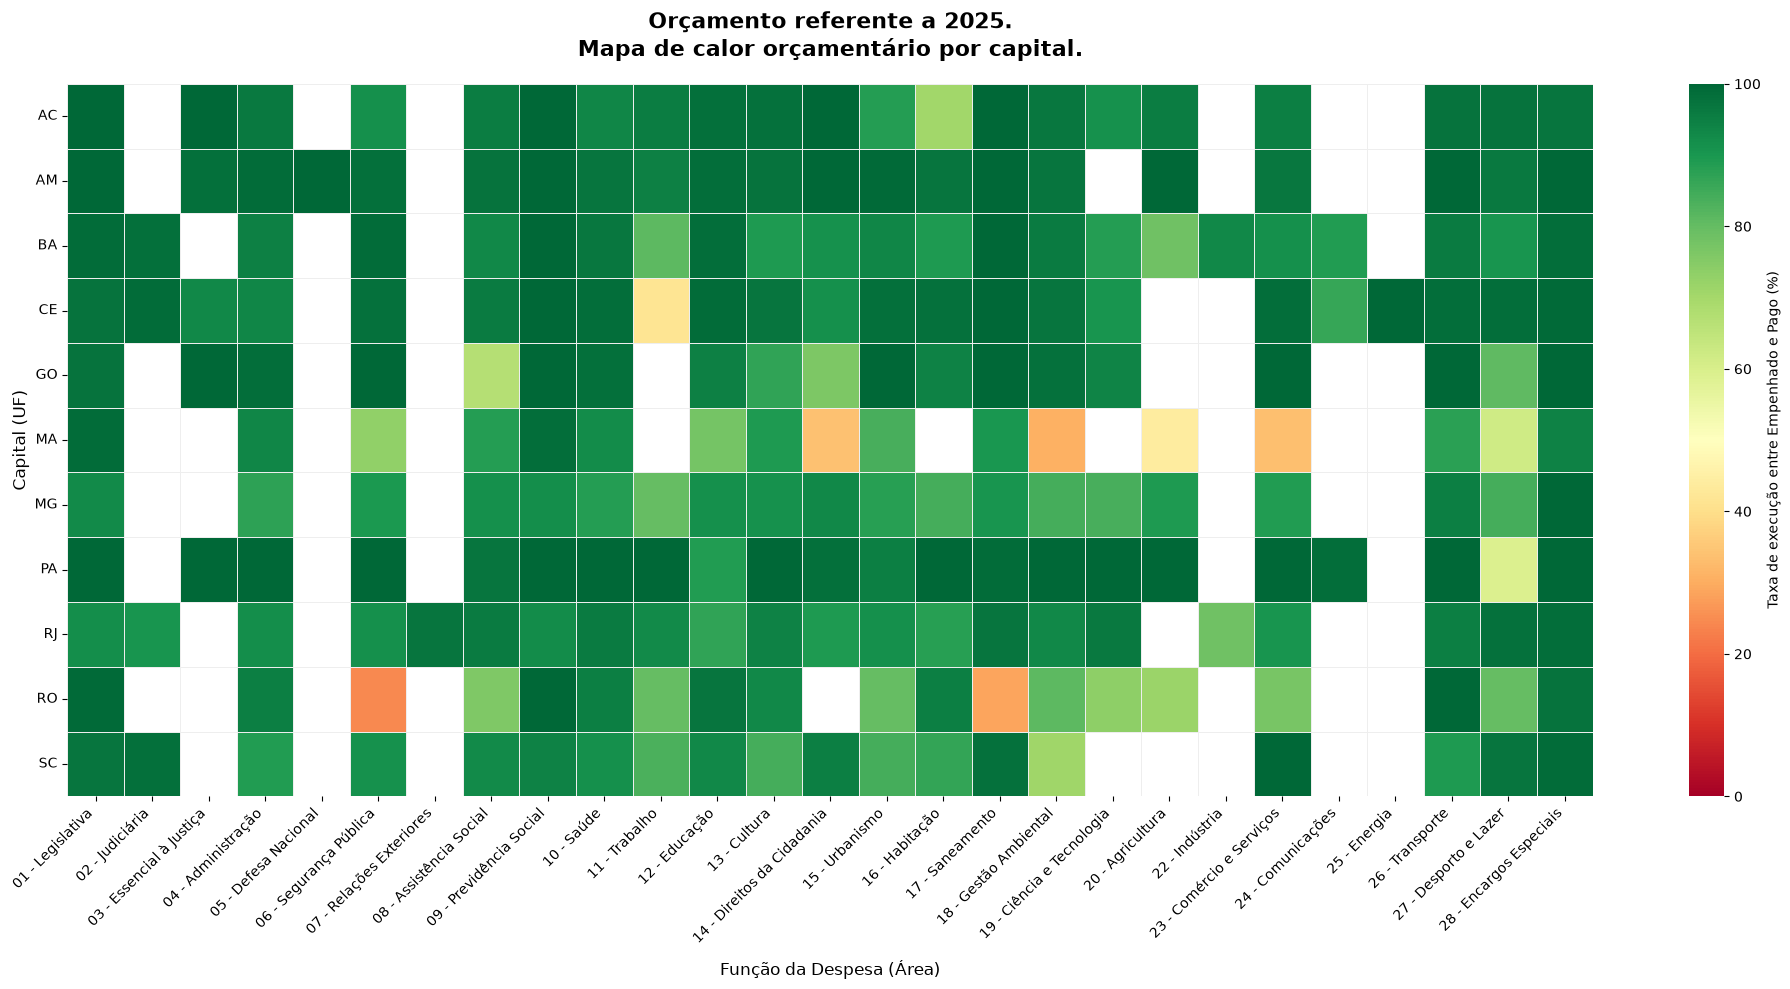

In [6]:
# Analisando o ano de 2025
criar_mapa_calor(df_pivot, 2025)

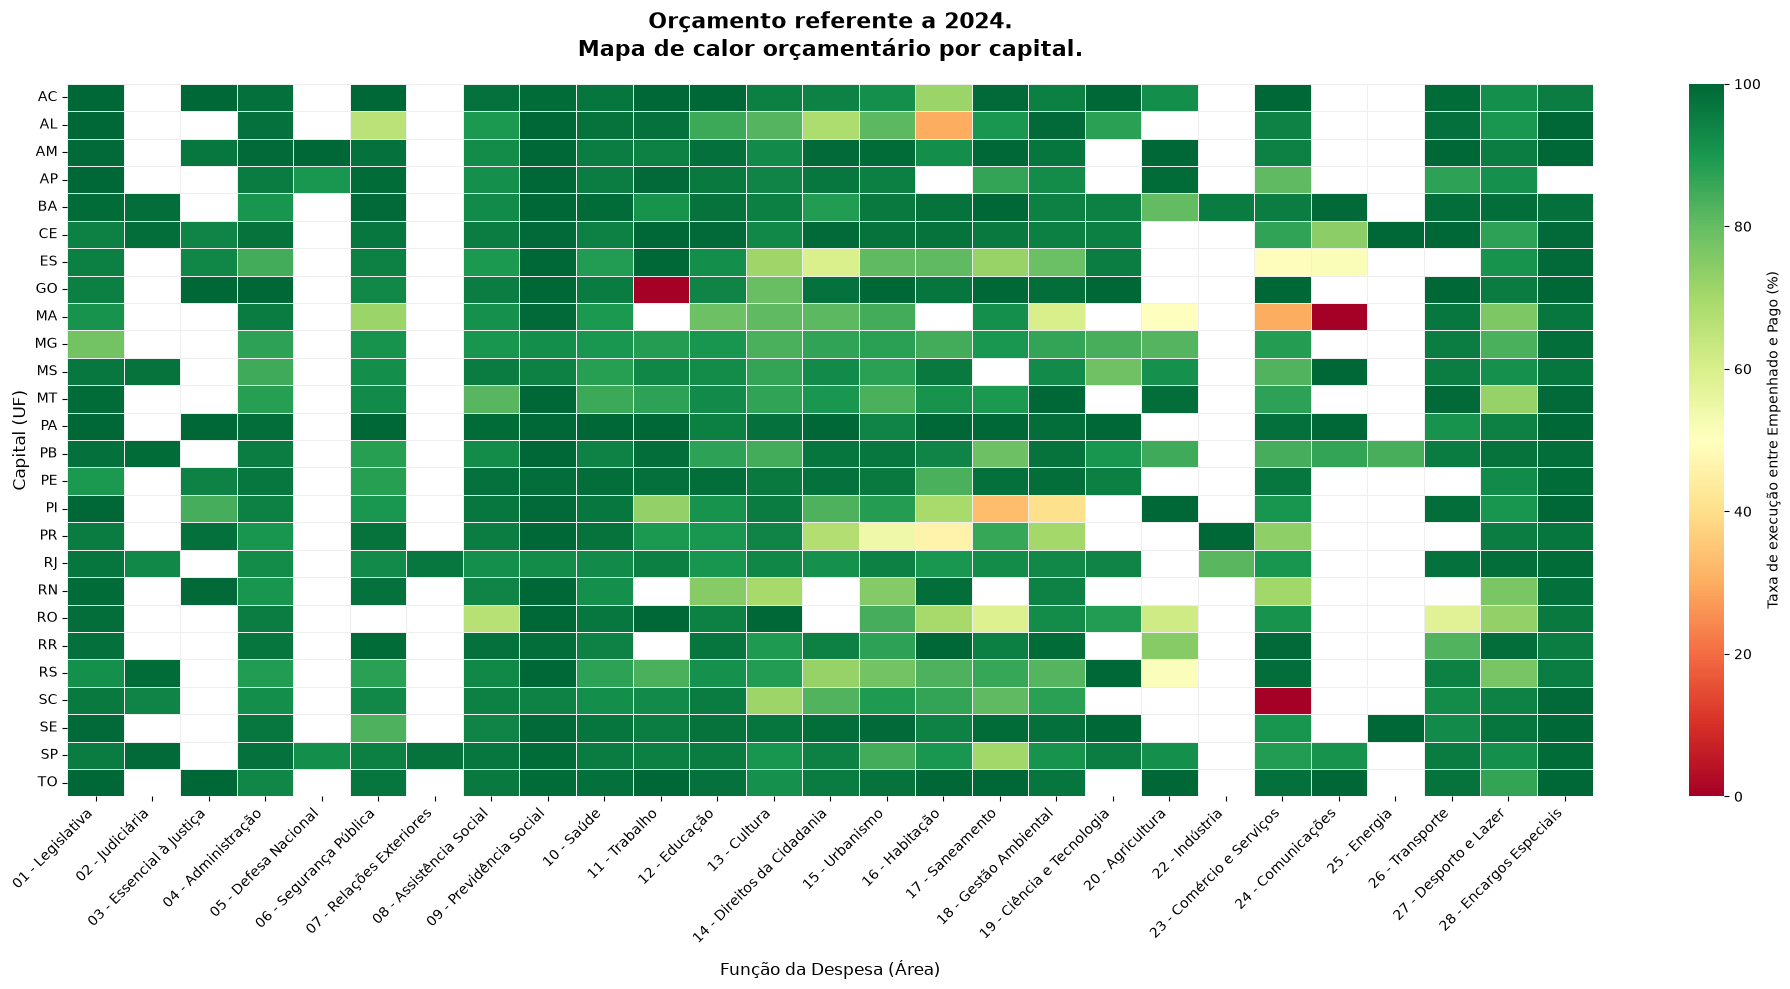

In [7]:
# Analisando o ano de 2024
criar_mapa_calor(df_pivot, 2024)

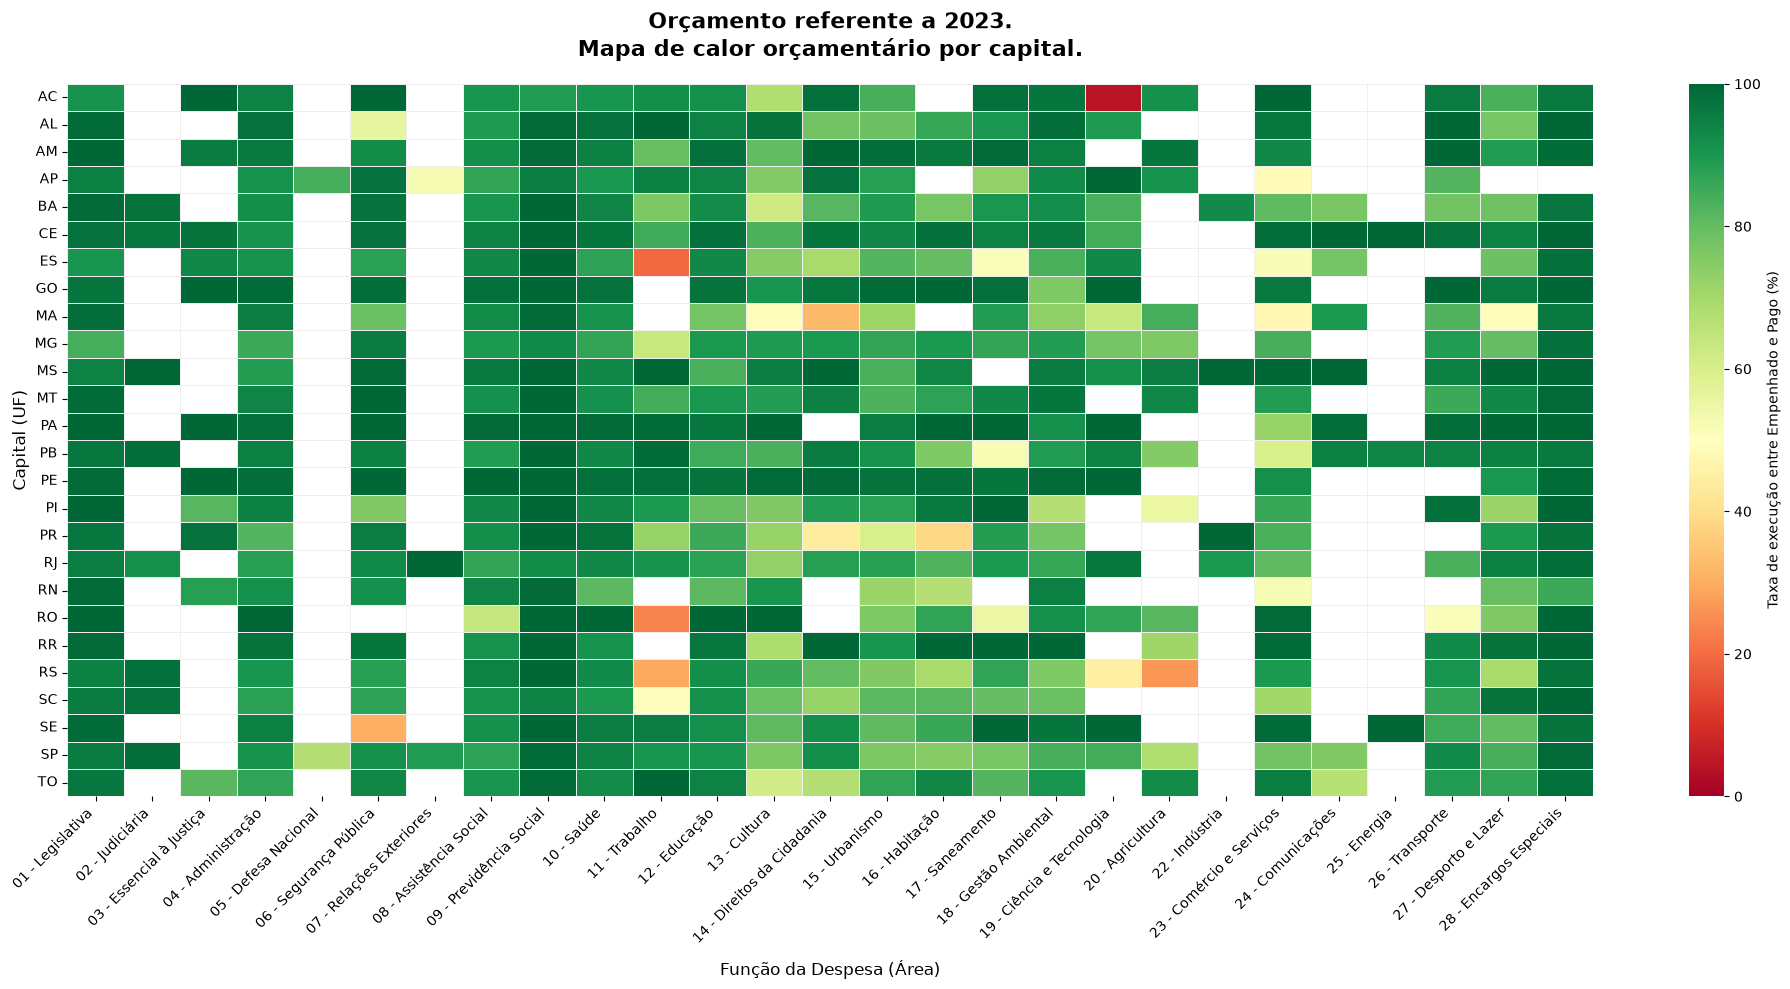

In [8]:
# Analisando o ano de 2023
criar_mapa_calor(df_pivot, 2023)

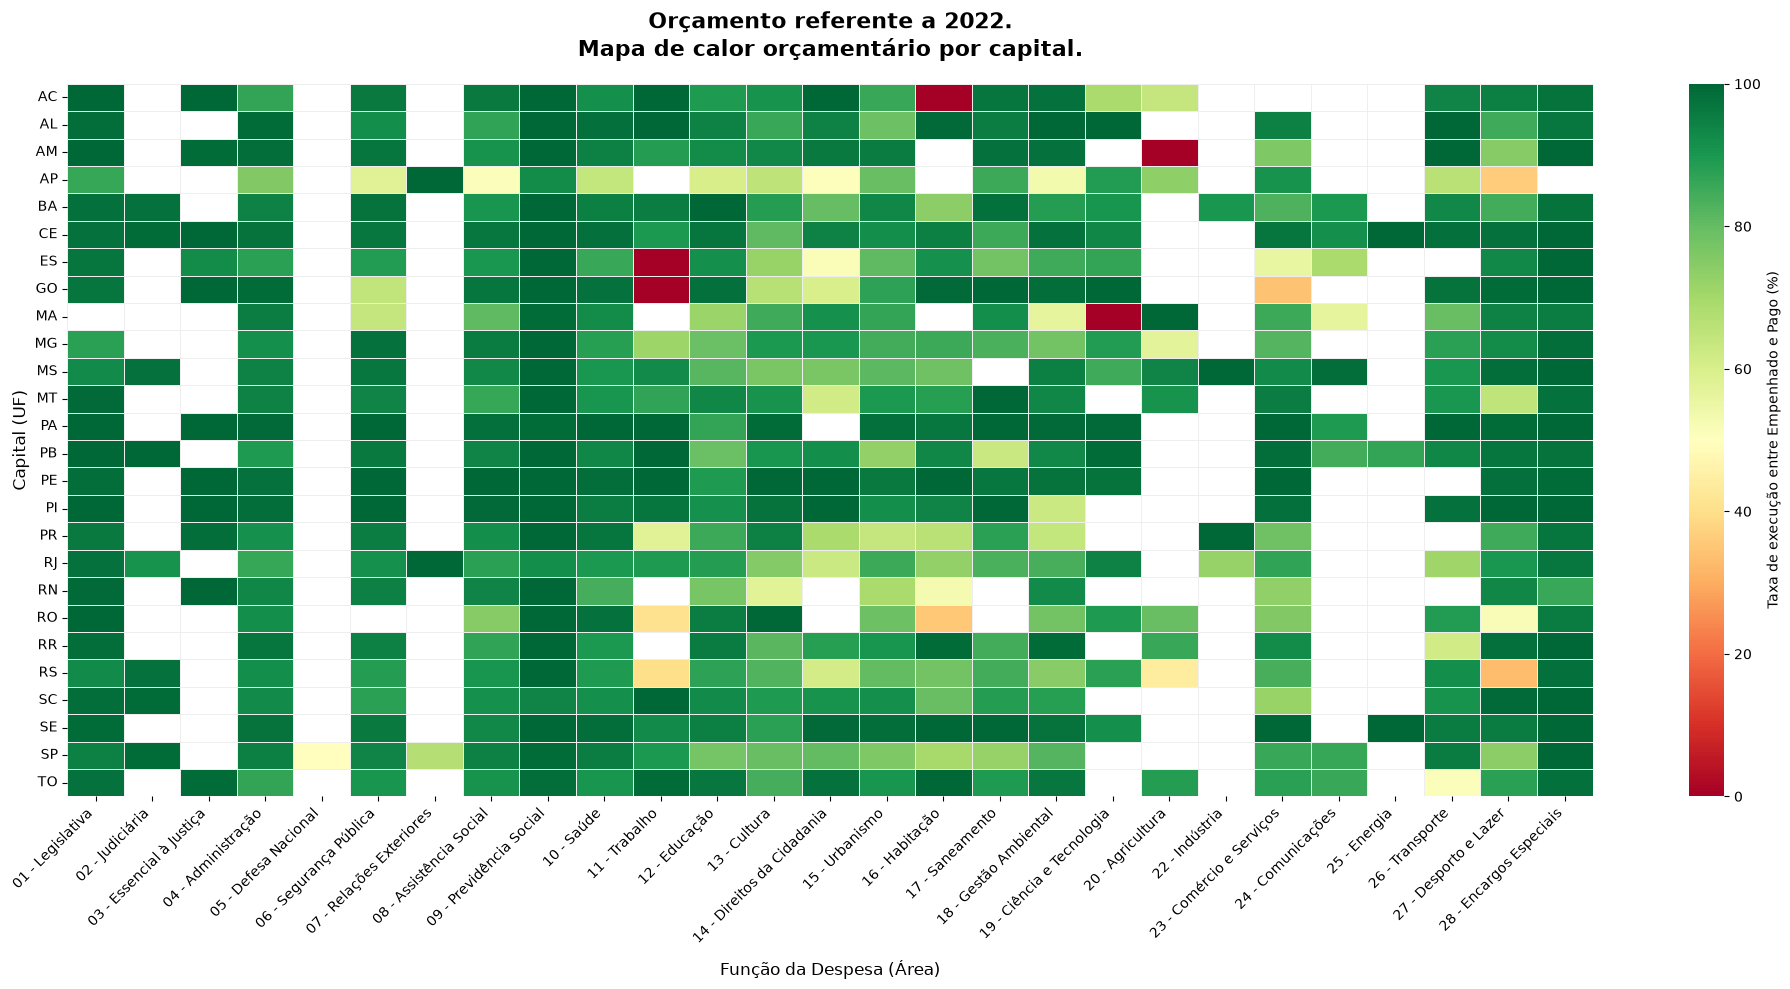

In [9]:
# Analisando o ano de 2022
criar_mapa_calor(df_pivot, 2022)

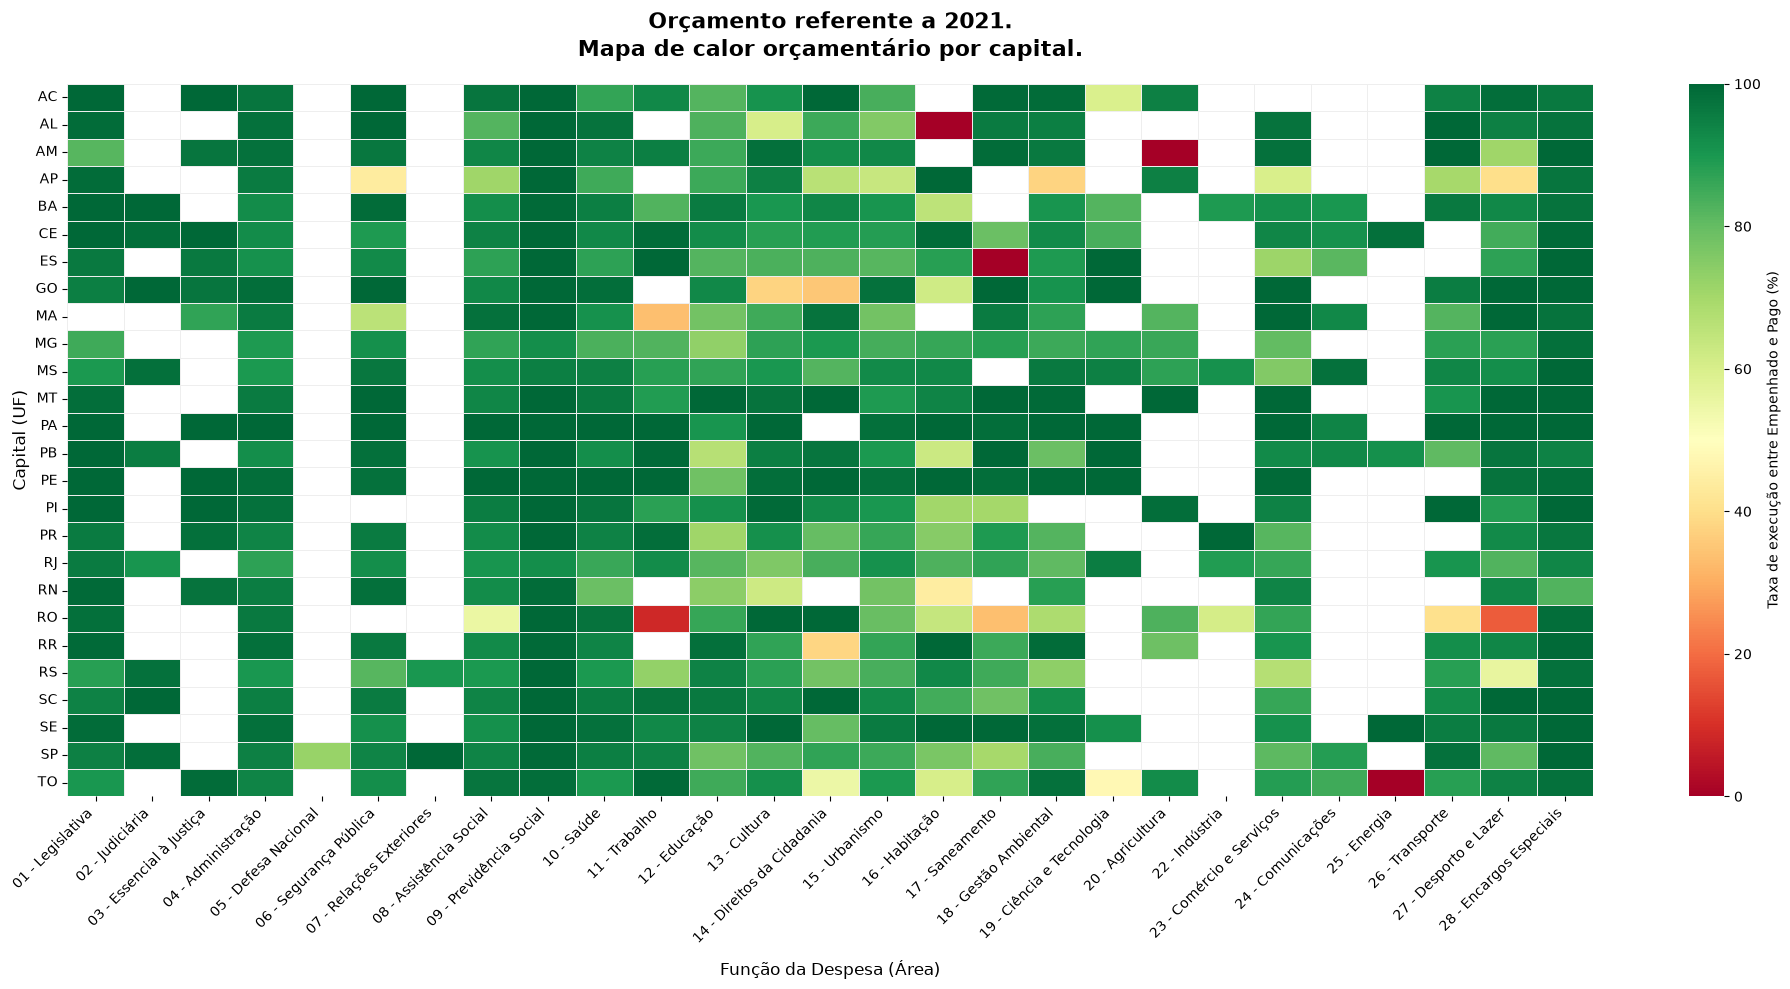

In [10]:
# Analisando o ano de 2021
criar_mapa_calor(df_pivot, 2021)

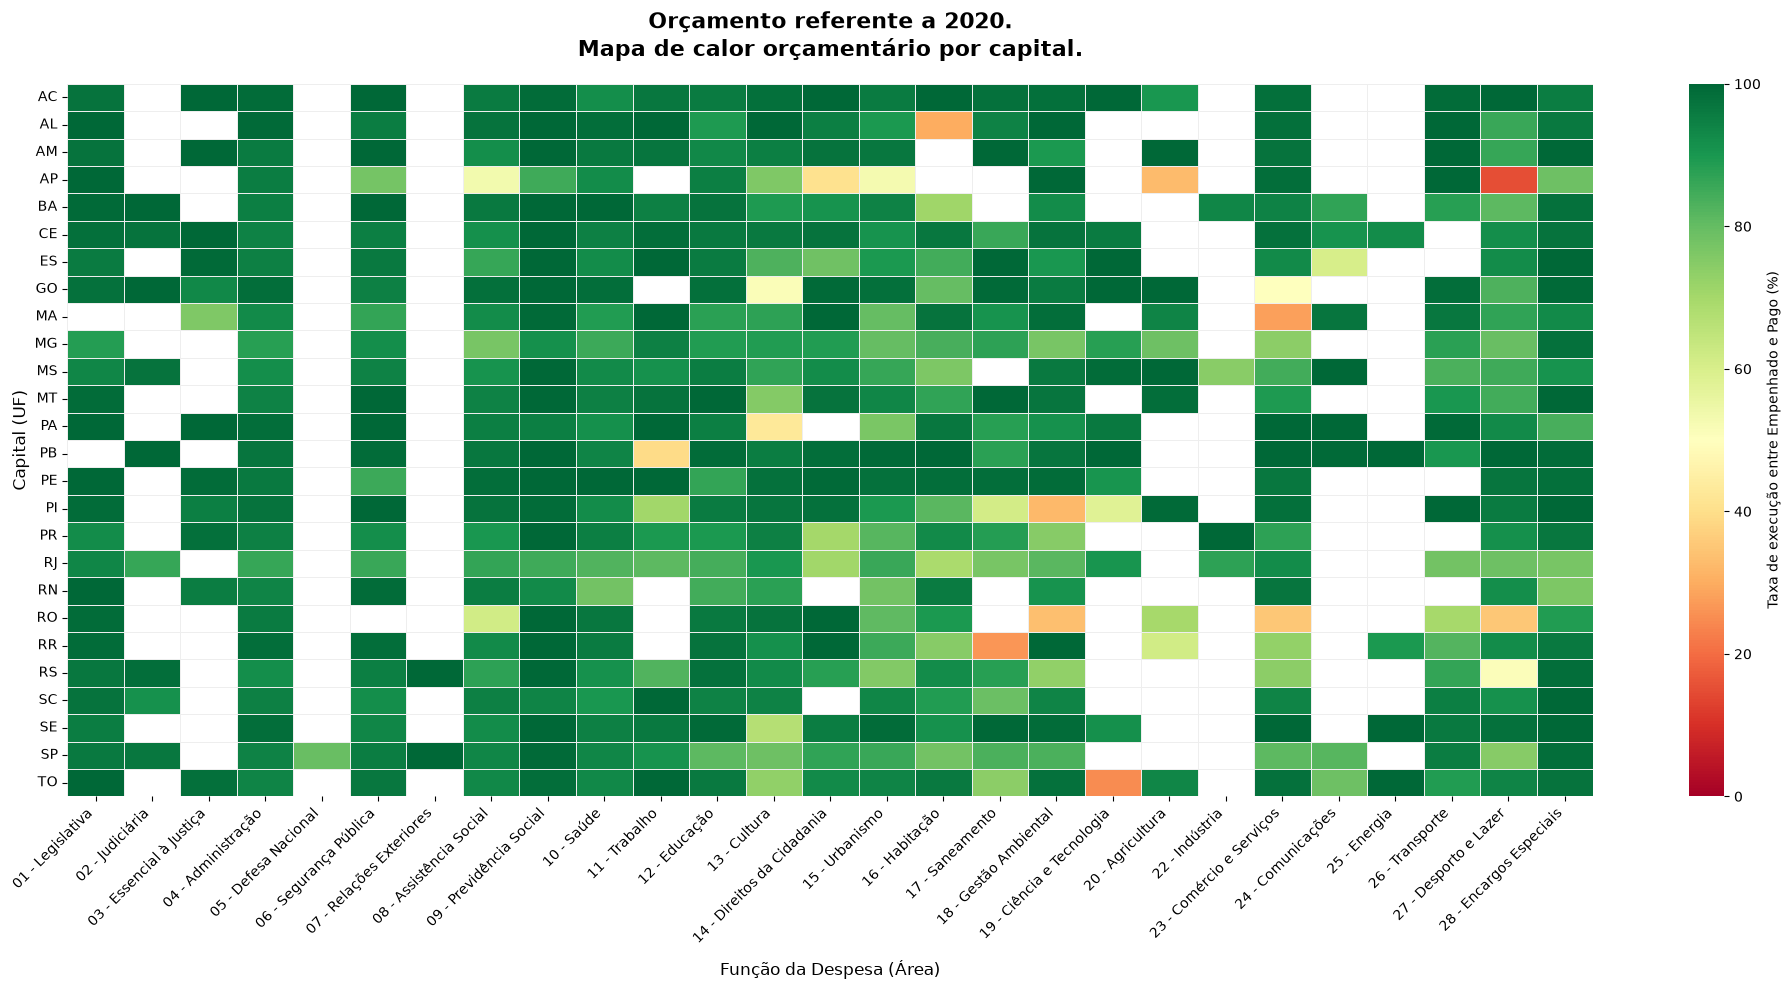

In [11]:
# Analisando o ano de 2020
criar_mapa_calor(df_pivot, 2020)

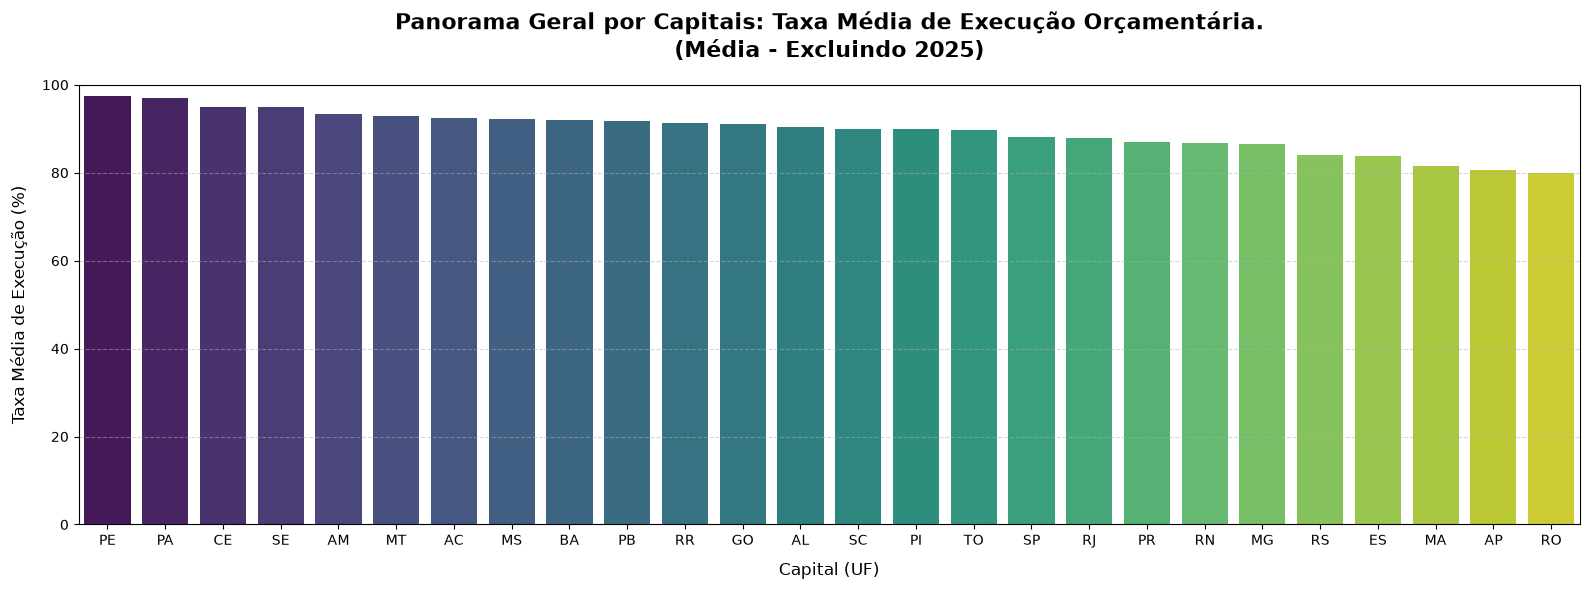

In [12]:
# Panorama por capitais

# Removendo 2025 da análise por ter dados incompletos
panorama_capitais = df_pivot[df_pivot['Ano'] != 2025].groupby("UF")["Taxa de Execução"].mean().reset_index()

# Simplificando valores enormes
panorama_capitais["Taxa Média (%)"] = panorama_capitais["Taxa de Execução"]

panorama_capitais = panorama_capitais.sort_values(by="Taxa Média (%)", ascending=False)

# Gerando em gráficos
plt.figure(figsize=(16, 6))
sns.barplot(
    data=panorama_capitais,
    x="UF",
    y="Taxa Média (%)",
    palette="viridis",
    hue="UF",
    legend=False
)

# Estilizando
plt.title(f"Panorama Geral por Capitais: Taxa Média de Execução Orçamentária.\n(Média - Excluindo 2025)", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Capital (UF)", fontsize=12, labelpad=10)
plt.ylabel("Taxa Média de Execução (%)", fontsize=12, labelpad=10)
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()


Melhor análise em [README](./README.md)